<a href="https://colab.research.google.com/github/Laere11/Laere11/blob/Batteries/040425_fordfocus_ev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
04/04/25 full charge Ford Focus EV AUX battery cell voltages, last balancing event was on 3/12/25

Detailed Cell Data:
    cell  voltage  board  mV_from_avg   z_score
0      1   4.0655      0          6.8  0.792184
1      2   4.0625      0          3.8  0.442691
2      3   4.0643      0          5.6  0.652387
3      4   4.0605      0          1.8  0.209696
4      5   4.0619      0          3.2  0.372792
..   ...      ...    ...          ...       ...
81    82   4.0620      6          3.3  0.384442
82    83   4.0614      7          2.7  0.314544
83    84   4.0584      7         -0.3 -0.034949
84    85   4.0589      7          0.2  0.023300
85    86   4.0590      7          0.3  0.034949

[86 rows x 5 columns]


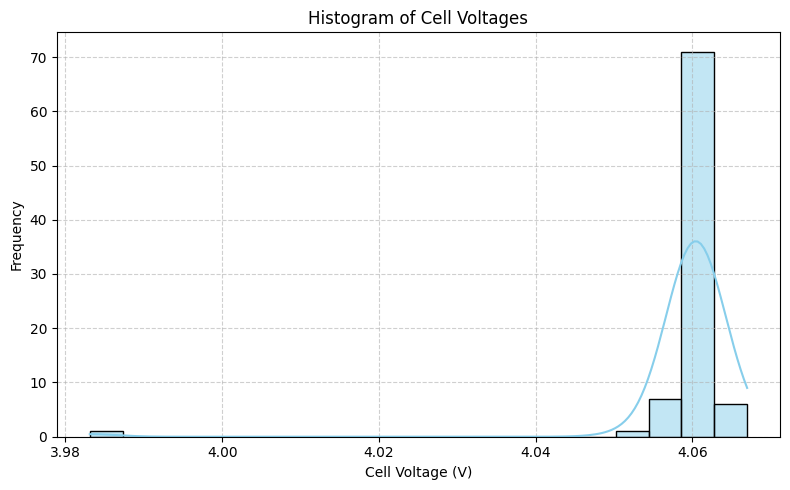

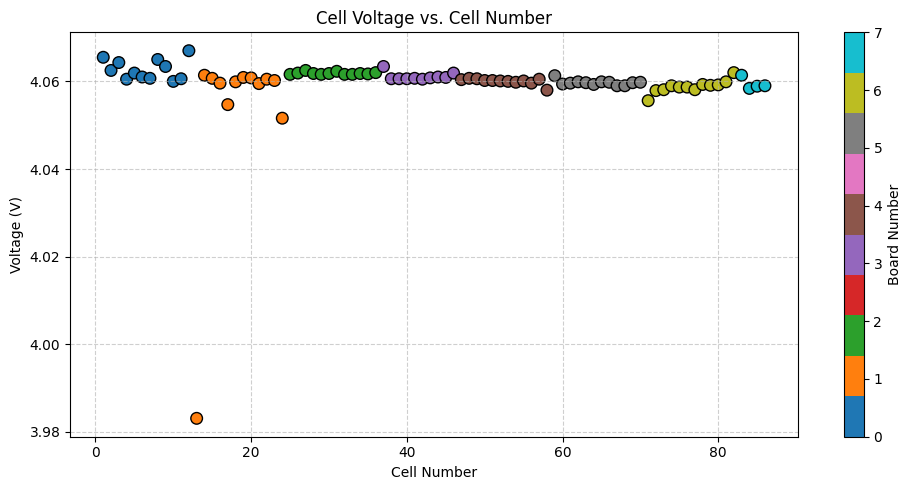

<ipython-input-1-e45e244e9fc3>:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='board', y='voltage', data=df, palette="pastel")


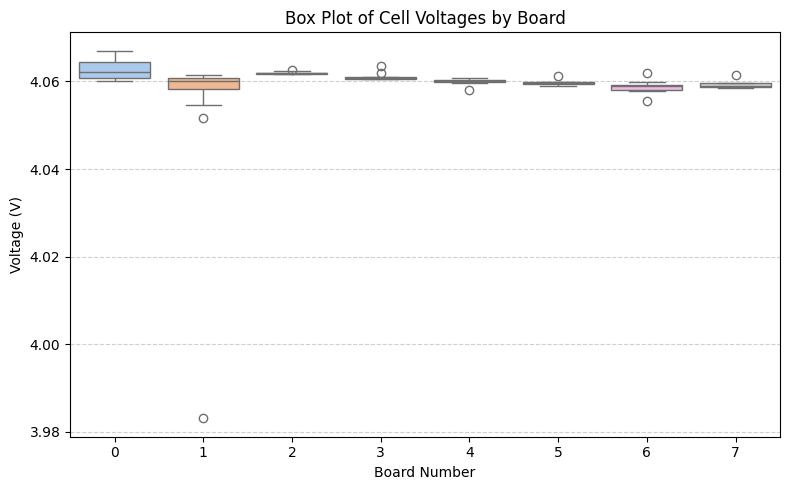

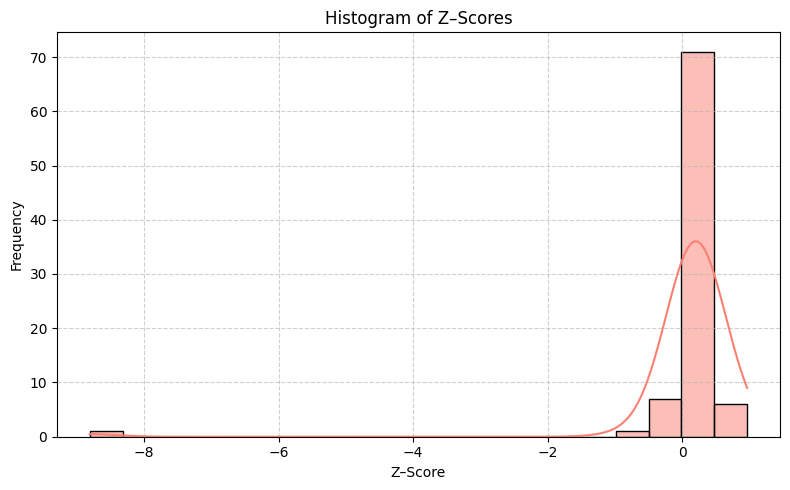

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Data Setup
# ---------------------------
# Define voltages for each board (board 0 to board 7)
board0 = [4.0655, 4.0625, 4.0643, 4.0605, 4.0619, 4.0610, 4.0607, 4.0650, 4.0634, 4.0600, 4.0606, 4.0670]
board1 = [3.9831, 4.0614, 4.0607, 4.0596, 4.0547, 4.0599, 4.0609, 4.0608, 4.0595, 4.0605, 4.0602, 4.0516]
board2 = [4.0616, 4.0619, 4.0625, 4.0618, 4.0616, 4.0618, 4.0623, 4.0616, 4.0616, 4.0618, 4.0617, 4.0620]
board3 = [4.0634, 4.0606, 4.0606, 4.0606, 4.0607, 4.0605, 4.0608, 4.0610, 4.0609, 4.0619]
board4 = [4.0604, 4.0607, 4.0606, 4.0602, 4.0602, 4.0601, 4.0600, 4.0598, 4.0601, 4.0596, 4.0605, 4.0580]
board5 = [4.0613, 4.0594, 4.0596, 4.0599, 4.0597, 4.0593, 4.0599, 4.0598, 4.0590, 4.0590, 4.0597, 4.0598]
board6 = [4.0556, 4.0579, 4.0581, 4.0590, 4.0587, 4.0587, 4.0581, 4.0593, 4.0591, 4.0592, 4.0599, 4.0620]
board7 = [4.0614, 4.0584, 4.0589, 4.0590]

# Concatenate all boards to create the full list of cell voltages
voltages = board0 + board1 + board2 + board3 + board4 + board5 + board6 + board7

# Create board labels for each cell
boards = (
    [0]*len(board0) +
    [1]*len(board1) +
    [2]*len(board2) +
    [3]*len(board3) +
    [4]*len(board4) +
    [5]*len(board5) +
    [6]*len(board6) +
    [7]*len(board7)
)

# Create cell numbers (1-indexed)
cells = list(range(1, len(voltages) + 1))

# Given overall average voltage from header
avgV = 4.0587

# ---------------------------
# Create DataFrame & Compute Metrics
# ---------------------------
df = pd.DataFrame({
    'cell': cells,
    'voltage': voltages,
    'board': boards
})

# Compute the overall standard deviation from the data
sigma = df['voltage'].std()

# Compute the difference from the average in mV and the Z–score
df['mV_from_avg'] = (df['voltage'] - avgV) * 1000  # in millivolts
df['z_score'] = (df['voltage'] - avgV) / sigma

# Display the detailed cell data
print("Detailed Cell Data:")
print(df)

# ---------------------------
# Plot 1: Histogram of Cell Voltages
# ---------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df['voltage'], bins=20, kde=True, color='skyblue')
plt.xlabel("Cell Voltage (V)")
plt.ylabel("Frequency")
plt.title("Histogram of Cell Voltages")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------
# Plot 2: Scatter Plot - Cell Voltage vs. Cell Number
# ---------------------------
plt.figure(figsize=(10, 5))
scatter = plt.scatter(df['cell'], df['voltage'], c=df['board'], cmap="tab10", s=70, edgecolor='k')
plt.xlabel("Cell Number")
plt.ylabel("Voltage (V)")
plt.title("Cell Voltage vs. Cell Number")
plt.colorbar(scatter, label="Board Number")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------
# Plot 3: Box Plot by Board
# ---------------------------
# Note: To address deprecation warnings, if no hue is specified, we assign x as the hue and disable the legend.
plt.figure(figsize=(8, 5))
sns.boxplot(x='board', y='voltage', data=df, palette="pastel")
plt.xlabel("Board Number")
plt.ylabel("Voltage (V)")
plt.title("Box Plot of Cell Voltages by Board")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------
# Plot 4: Histogram of Z–Scores
# ---------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df['z_score'], bins=20, kde=True, color='salmon')
plt.xlabel("Z–Score")
plt.ylabel("Frequency")
plt.title("Histogram of Z–Scores")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Below is an example of how you might summarize the long‐term trends in cell performance since the 3/12/25 balancing event. (Note: This new 04/04/25 dataset represents a full‐charge condition and has not been balanced since 3/12/25.) Over the past few weeks, you’ve observed gradually increasing variation among cells—with cell #13, in particular, showing a marked decline in voltage relative to the pack average.

For example, using two representative datasets we have available:

Date	Days Since Balancing	Pack Voltage (V)	Avg Cell Voltage (V)	Cell #13 Voltage (V)	Voltage Range (mV)
03/23/25	11	349.0927	4.0592	4.0196	42.3
04/04/25	23	349.0524	4.0587	3.9831	80.3
In this table, “Days Since Balancing” is calculated from the 3/12/25 balancing event. Notice that cell #13 has dropped from 4.0196 V to 3.9831 V over roughly 12 days—while the overall pack average remains nearly constant, the range of cell voltages nearly doubles.

A visualization of the decline in cell #13’s voltage over time (and, if desired, the change in range) can help reveal the rate of degradation. For example, the line plot below shows the voltage of cell #13 versus days since balancing:

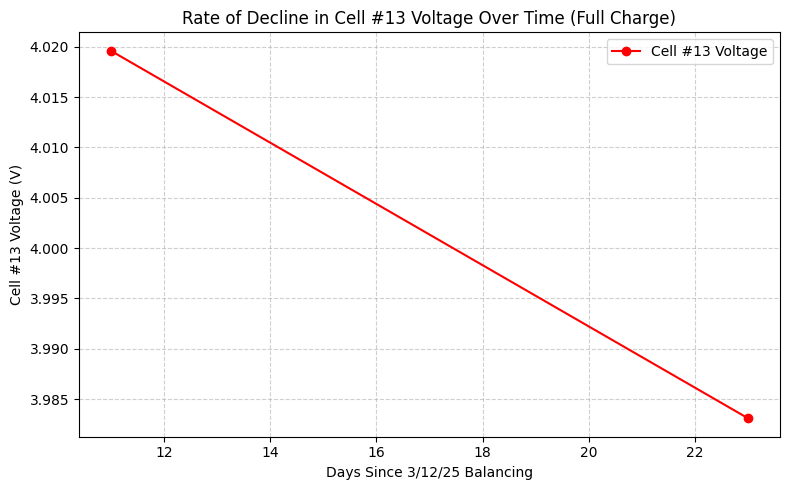

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame with the trend data
trend_data = {
    "Date": ["03/23/25", "04/04/25"],
    "Days_Since_Balancing": [11, 23],
    "Avg_Voltage": [4.0592, 4.0587],
    "Cell_13_Voltage": [4.0196, 3.9831],
    "Voltage_Range_mV": [42.3, 80.3]
}

df_trend = pd.DataFrame(trend_data)

# Plot the decline of cell #13 voltage over time
plt.figure(figsize=(8, 5))
plt.plot(df_trend["Days_Since_Balancing"], df_trend["Cell_13_Voltage"],
         marker='o', linestyle='-', color='red', label='Cell #13 Voltage')
plt.xlabel("Days Since 3/12/25 Balancing")
plt.ylabel("Cell #13 Voltage (V)")
plt.title("Rate of Decline in Cell #13 Voltage Over Time (Full Charge)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


is there a reference of cell #13 when fully balance on 03/12/25?  it should have been near 4.06V.  I would like you to update the graph to represent the voltage from the starting day 0 on 3/12/25, with this additional 3rd data point to see if the drop in volts per day is linear or not?  Please offer the best fit linear equation value for reference.


ChatGPT said:
Reasoned for 47 seconds
Below is an updated analysis focusing on cell #13. We now include a reference baseline from the 03/12/25 balancing event—when cell #13 was approximately 4.06 V—and add the two later measurements. In summary, we have:

Date	Days Since Balancing (3/12/25)	Cell #13 Voltage (V)
03/12/25	0	4.06
03/23/25	11	4.0196
04/04/25	23	3.9831
Using these three data points, a linear regression yields the best fit equation for cell #13’s voltage decline over time. The calculated slope is approximately –0.00334 V/day and the intercept is about 4.0587 V, giving the equation:

  V = 4.0587 – 0.00334·(days since 3/12/25)

This indicates that cell #13 is losing roughly 3.34 mV per day. The following Python code produces a plot of these data points along with the best-fit line.

Best-fit linear equation: V = 4.0587 - 0.00334 * (days since 3/12/25)


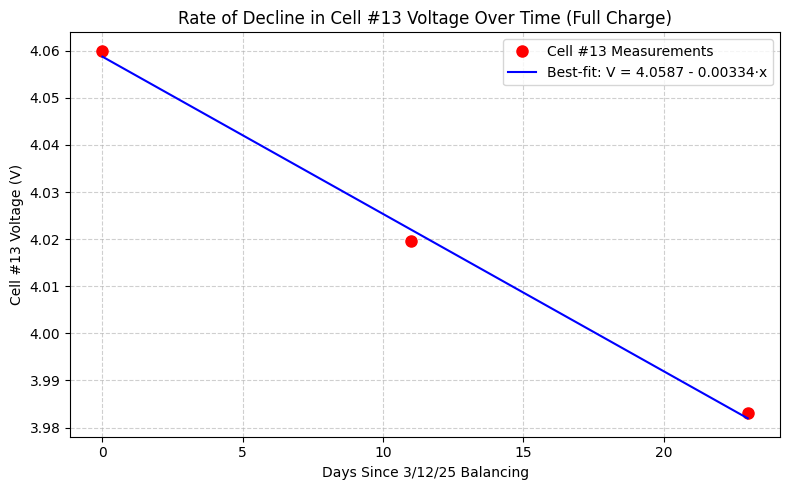

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define the three data points for cell #13:
# Day 0 (03/12/25): 4.06 V (baseline when balanced)
# Day 11 (03/23/25): 4.0196 V
# Day 23 (04/04/25): 3.9831 V
days = np.array([0, 11, 23])
voltages = np.array([4.06, 4.0196, 3.9831])

# Fit a linear regression (degree 1 polynomial)
coeffs = np.polyfit(days, voltages, 1)
slope, intercept = coeffs
# Create the best-fit line function
best_fit_line = np.poly1d(coeffs)

# Generate x values for plotting the regression line
x_fit = np.linspace(0, 23, 100)
y_fit = best_fit_line(x_fit)

# Print the best-fit linear equation
print(f"Best-fit linear equation: V = {intercept:.4f} - {abs(slope):.5f} * (days since 3/12/25)")
# (The equation is printed as a subtraction since slope is negative)

# Plot the data points and the best-fit line
plt.figure(figsize=(8, 5))
plt.plot(days, voltages, 'ro', markersize=8, label='Cell #13 Measurements')
plt.plot(x_fit, y_fit, 'b-', label=f'Best-fit: V = {intercept:.4f} - {abs(slope):.5f}·x')
plt.xlabel("Days Since 3/12/25 Balancing")
plt.ylabel("Cell #13 Voltage (V)")
plt.title("Rate of Decline in Cell #13 Voltage Over Time (Full Charge)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


Summary:
At full charge and after the initial balancing on 03/12/25, cell #13 was near 4.06 V. Over the next 11 days (by 03/23/25) its voltage dropped to about 4.0196 V, and by 23 days (04/04/25) it further declined to approximately 3.9831 V. The best-fit linear regression indicates a decline of roughly 3.34 mV per day. This plot and equation provide a clear visualization of the rate of degradation for cell #13 over time.